In [1]:
import sys
sys.path.insert(0, '../..')

import warnings
warnings.filterwarnings('ignore')

import os
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from collections import defaultdict

from src.utils.config import settings
from src.utils.logger import get_logger

log = get_logger("products_domain")

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

PROC     = '../../data/processed/'
PRODUCTS = '../../data/cross_domain/products/'
Path(PRODUCTS).mkdir(
    parents=True, exist_ok=True)

print(f"✅ Imports ready")
print(f"   Device : {device}")

✅ Imports ready
   Device : cpu


In [2]:
# Generate Synthetic Amazon Data
print("GENERATING SYNTHETIC AMAZON DATA")
print("=" * 55)
print("""
Realistic Amazon Reviews 2023 properties:
  Multi-category product catalog
  Purchase funnel: view → cart → purchase
  Star ratings (1-5) + verified purchase
  Temporal patterns (seasonal buying)
  Product categories + subcategories
""")

np.random.seed(42)

N_USERS    = 2000
N_PRODUCTS = 800
N_INTERACTIONS = 40000

# ── Product catalog ───────────────────────────────
CATEGORIES = {
    'Electronics':  ['Phones', 'Laptops',
                     'Headphones', 'Cameras'],
    'Books':        ['Fiction', 'Non-Fiction',
                     'Technical', 'Biography'],
    'Clothing':     ['Men', 'Women',
                     'Kids', 'Sports'],
    'Home':         ['Kitchen', 'Furniture',
                     'Garden', 'Decor'],
    'Sports':       ['Fitness', 'Outdoor',
                     'Team Sports', 'Yoga'],
}

INTERACTION_TYPES = {
    'view':     1,
    'wishlist': 2,
    'cart':     3,
    'purchase': 5,
    'review':   4,
}

products = []
for i in range(N_PRODUCTS):
    cat = np.random.choice(
        list(CATEGORIES.keys()))
    subcat = np.random.choice(
        CATEGORIES[cat])

    # Price: log-normal distribution
    price = round(float(
        np.random.lognormal(3.5, 1.0)), 2)
    price = min(price, 2000.0)

    # Popularity: power law
    pop = int(
        np.random.pareto(1.8) * 50 + 1)
    pop = min(pop, 5000)

    # Rating: normal around 4.0
    avg_rating = min(5.0, max(1.0,
        np.random.normal(4.0, 0.5)))

    products.append({
        'product_id':   i,
        'product_name': f"Product_{i:04d}",
        'category':     cat,
        'subcategory':  subcat,
        'price':        price,
        'popularity':   pop,
        'avg_rating':   round(avg_rating, 1),
    })

products_df = pd.DataFrame(products)

# ── Generate interactions ─────────────────────────
# Users have category preferences
user_pref_cat = np.random.choice(
    list(CATEGORIES.keys()),
    size=N_USERS)

interactions = []

for uid in range(N_USERS):
    pref_cat  = user_pref_cat[uid]
    n_ints    = np.random.randint(10, 60)

    # 60% from preferred category
    pref_prods = products_df[
        products_df['category'] == pref_cat
    ]['product_id'].values
    other_prods = products_df[
        products_df['category'] != pref_cat
    ]['product_id'].values

    n_pref  = int(n_ints * 0.6)
    n_other = n_ints - n_pref

    chosen_pref = np.random.choice(
        pref_prods,
        size=min(n_pref, len(pref_prods)),
        replace=False)
    chosen_other = np.random.choice(
        other_prods,
        size=min(n_other, len(other_prods)),
        replace=False)

    all_chosen = list(chosen_pref) + \
                 list(chosen_other)

    for pid in all_chosen:
        # Interaction type — funnel stages
        # Most users just view
        # Few actually purchase
        int_type = np.random.choice(
            list(INTERACTION_TYPES.keys()),
            p=[0.50, 0.10, 0.20,
               0.15, 0.05])

        weight = INTERACTION_TYPES[int_type]

        # Rating only for purchases/reviews
        rating = None
        if int_type in ['purchase', 'review']:
            rating = round(float(min(5.0,
                max(1.0,
                np.random.normal(4.0, 0.8)))),
                1)

        ts = int(time.time()) - \
             np.random.randint(
                 0, 2*365*24*3600)

        interactions.append({
            'user_id':        uid,
            'product_id':     int(pid),
            'interaction':    int_type,
            'weight':         weight,
            'rating':         rating,
            'timestamp':      ts,
            'verified_purchase':
                int_type == 'purchase',
        })

interactions_df = pd.DataFrame(interactions)

# Save
products_df.to_csv(
    PRODUCTS + 'products.csv', index=False)
interactions_df.to_csv(
    PRODUCTS + 'interactions.csv',
    index=False)

print(f"✅ Amazon Products data generated")
print(f"   Users        : {N_USERS:,}")
print(f"   Products     : {N_PRODUCTS:,}")
print(f"   Interactions : "
      f"{len(interactions_df):,}")
print(f"\nInteraction type breakdown:")
print(interactions_df['interaction']\
    .value_counts().to_string())
print(f"\nSample:")
print(interactions_df.head(5))

GENERATING SYNTHETIC AMAZON DATA

Realistic Amazon Reviews 2023 properties:
  Multi-category product catalog
  Purchase funnel: view → cart → purchase
  Star ratings (1-5) + verified purchase
  Temporal patterns (seasonal buying)
  Product categories + subcategories

✅ Amazon Products data generated
   Users        : 2,000
   Products     : 800
   Interactions : 68,354

Interaction type breakdown:
interaction
view        34228
cart        13601
purchase    10294
wishlist     6740
review       3491

Sample:
   user_id  product_id interaction  weight  rating   timestamp  \
0        0         358    purchase       5     3.4  1763018570   
1        0         752    purchase       5     4.1  1722875430   
2        0         363        view       1     NaN  1761869009   
3        0         255    wishlist       2     NaN  1754000833   
4        0         458    purchase       5     1.4  1755432904   

   verified_purchase  
0               True  
1               True  
2              False  

PRODUCT DOMAIN EDA


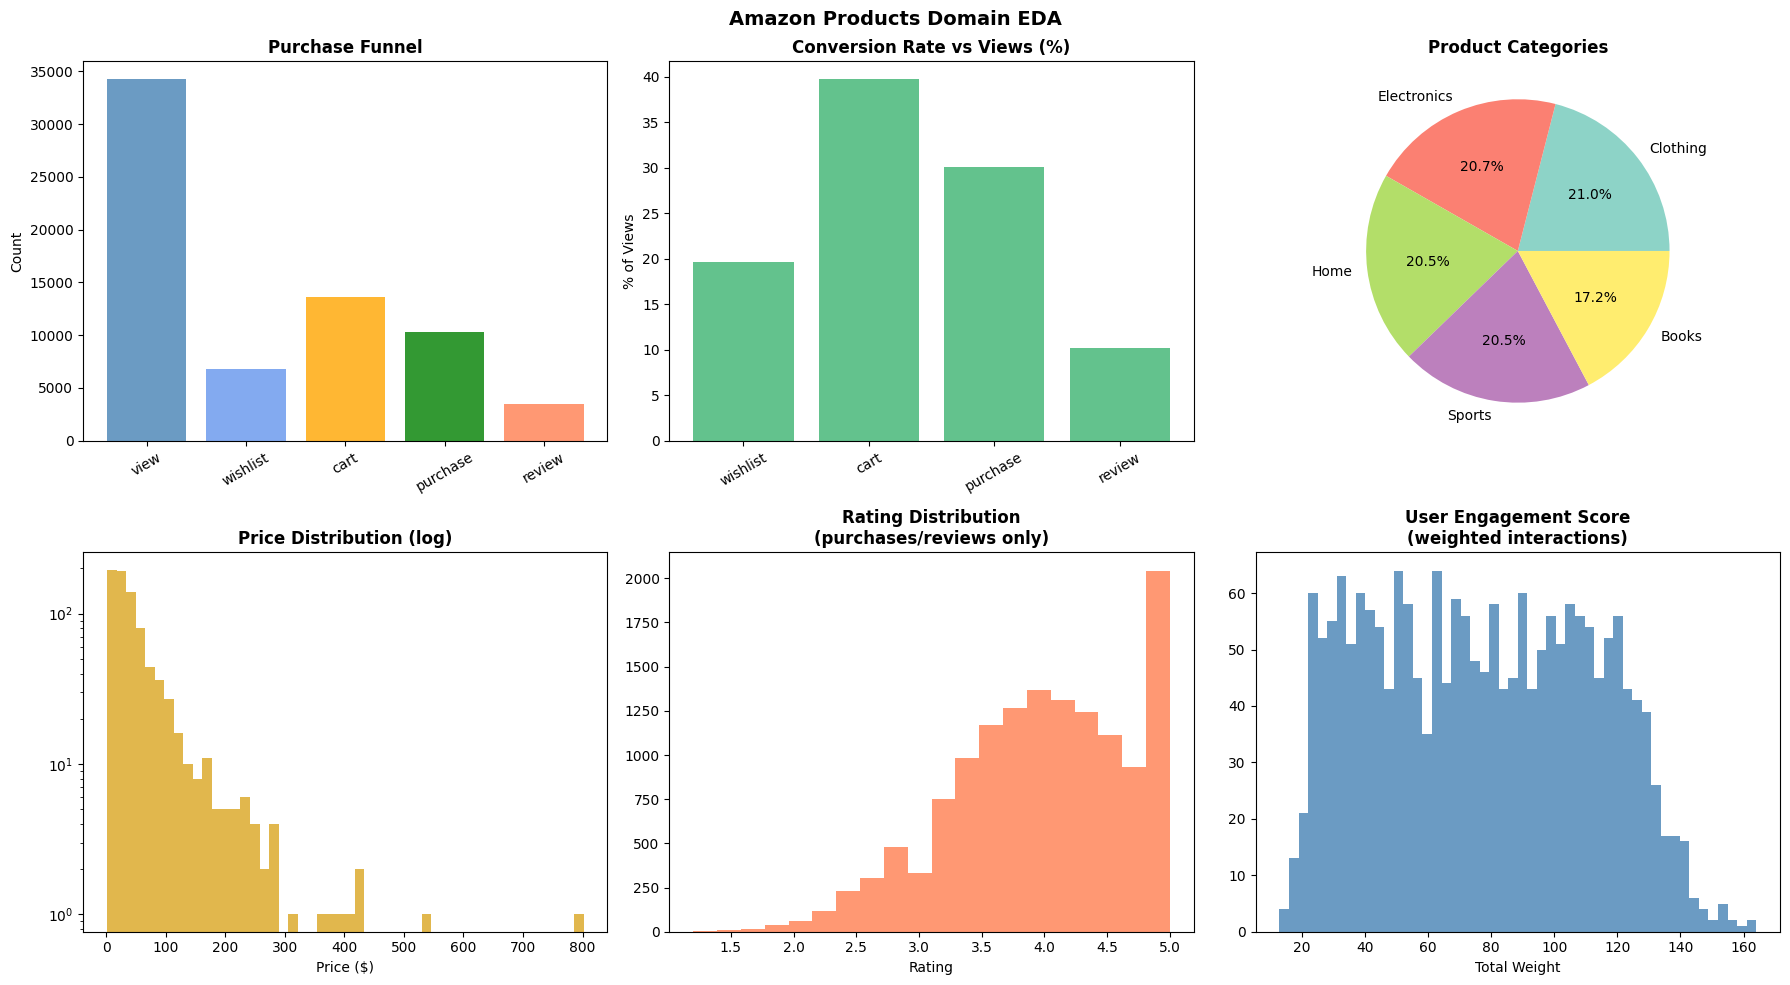


Purchase funnel stats:
  Views      : 34,228
  Carts      : 13,601
  Purchases  : 10,294
  View→Cart  : 39.7%
  View→Buy   : 30.1%


In [3]:
# EDA + Funnel Analysis
print("PRODUCT DOMAIN EDA")
print("=" * 55)

fig, axes = plt.subplots(
    2, 3, figsize=(18, 10))

# Interaction funnel
funnel_counts = interactions_df[
    'interaction'].value_counts()
funnel_order  = ['view', 'wishlist',
                  'cart', 'purchase',
                  'review']
funnel_vals   = [
    funnel_counts.get(f, 0)
    for f in funnel_order]

axes[0,0].bar(
    funnel_order, funnel_vals,
    color=['steelblue', 'cornflowerblue',
           'orange', 'green', 'coral'],
    alpha=0.8)
axes[0,0].set_title(
    'Purchase Funnel',
    fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(
    axis='x', rotation=30)

# Conversion rates
total_views = funnel_counts.get('view', 1)
conv_rates  = {
    f: funnel_counts.get(f, 0)/total_views*100
    for f in funnel_order[1:]}
axes[0,1].bar(
    list(conv_rates.keys()),
    list(conv_rates.values()),
    color='mediumseagreen', alpha=0.8)
axes[0,1].set_title(
    'Conversion Rate vs Views (%)',
    fontweight='bold')
axes[0,1].set_ylabel('% of Views')
axes[0,1].tick_params(
    axis='x', rotation=30)

# Category distribution
cat_counts = products_df[
    'category'].value_counts()
axes[0,2].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3(
        np.linspace(0, 1,
                    len(cat_counts))))
axes[0,2].set_title(
    'Product Categories',
    fontweight='bold')

# Price distribution
axes[1,0].hist(
    products_df['price'],
    bins=50, color='goldenrod',
    alpha=0.8, log=True)
axes[1,0].set_title(
    'Price Distribution (log)',
    fontweight='bold')
axes[1,0].set_xlabel('Price ($)')

# Rating distribution
purchase_df = interactions_df[
    interactions_df['rating'].notna()]
axes[1,1].hist(
    purchase_df['rating'],
    bins=20, color='coral',
    alpha=0.8)
axes[1,1].set_title(
    'Rating Distribution\n'
    '(purchases/reviews only)',
    fontweight='bold')
axes[1,1].set_xlabel('Rating')

# User activity
user_ints = interactions_df.groupby(
    'user_id')['weight'].sum()
axes[1,2].hist(
    user_ints, bins=50,
    color='steelblue', alpha=0.8)
axes[1,2].set_title(
    'User Engagement Score\n'
    '(weighted interactions)',
    fontweight='bold')
axes[1,2].set_xlabel('Total Weight')

plt.suptitle(
    'Amazon Products Domain EDA',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    PROC + 'plots/25_products_eda.png',
    bbox_inches='tight')
plt.show()

# Funnel stats
print(f"\nPurchase funnel stats:")
print(f"  Views      : "
      f"{funnel_counts.get('view', 0):,}")
print(f"  Carts      : "
      f"{funnel_counts.get('cart', 0):,}")
print(f"  Purchases  : "
      f"{funnel_counts.get('purchase', 0):,}")
cart_rate = funnel_counts.get(
    'cart', 0) / max(
    funnel_counts.get('view', 1), 1) * 100
purch_rate = funnel_counts.get(
    'purchase', 0) / max(
    funnel_counts.get('view', 1), 1) * 100
print(f"  View→Cart  : {cart_rate:.1f}%")
print(f"  View→Buy   : {purch_rate:.1f}%")

In [4]:
# Build Product Sequences
print("BUILDING PRODUCT SEQUENCES")
print("=" * 55)
print("""
Key difference from movies/music:
  Use WEIGHTED interactions not just views
  purchase (weight=5) > cart (weight=3)
                      > view (weight=1)

  Include all interactions but
  positives = weight >= 3 (cart or purchase)
""")

# Positives = cart or purchase
POSITIVE_THRESHOLD = 3

positive_df = interactions_df[
    interactions_df['weight'] >=
    POSITIVE_THRESHOLD
].copy()

print(f"Positive interactions "
      f"(weight ≥ {POSITIVE_THRESHOLD}): "
      f"{len(positive_df):,}")

# Build vocabulary
unique_products = sorted(
    positive_df['product_id'].unique())
n_products      = len(unique_products)

PROD_PAD    = 0
PROD_OFFSET = 1

prod2token = {
    p: i + PROD_OFFSET
    for i, p in enumerate(unique_products)
}
token2prod = {
    v: k for k, v in prod2token.items()
}
prod_vocab_size = n_products + PROD_OFFSET

print(f"\nProduct vocabulary:")
print(f"  Products    : {n_products:,}")
print(f"  Vocab size  : {prod_vocab_size:,}")

# Build sequences — sorted by timestamp
prod_sequences = {}
pos_sorted = positive_df.sort_values(
    ['user_id', 'timestamp'])

for uid, grp in pos_sorted.groupby(
        'user_id'):
    tokens = [
        prod2token[pid]
        for pid in grp['product_id'].values
        if pid in prod2token
    ]
    if len(tokens) >= 3:
        prod_sequences[uid] = tokens[-50:]

print(f"  Users with sequences: "
      f"{len(prod_sequences):,}")

seq_lens = [
    len(s) for s in
    prod_sequences.values()]
print(f"  Avg seq length : "
      f"{np.mean(seq_lens):.1f}")

# Category map for diversity evaluation
prod_genre_map = dict(zip(
    products_df['product_id'],
    products_df.apply(
        lambda r: [r['category'],
                   r['subcategory']],
        axis=1)))

BUILDING PRODUCT SEQUENCES

Key difference from movies/music:
  Use WEIGHTED interactions not just views
  purchase (weight=5) > cart (weight=3)
                      > view (weight=1)

  Include all interactions but
  positives = weight >= 3 (cart or purchase)

Positive interactions (weight ≥ 3): 27,386

Product vocabulary:
  Products    : 800
  Vocab size  : 801
  Users with sequences: 1,979
  Avg seq length : 13.8


In [6]:
# Train GRank on Products
print("TRAINING GRANK ON PRODUCTS DOMAIN")
print("=" * 55)
print("Same GRank model — products domain\n")

# Reuse GRankModel
class GRankModel(nn.Module):
    def __init__(self, vocab_size,
                 embed_dim=64, n_heads=4,
                 n_layers=2, max_seq_len=50,
                 dropout=0.1):
        super().__init__()
        self.item_emb = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=PROD_PAD)
        self.pos_emb  = nn.Embedding(
            max_seq_len, embed_dim)
        encoder_layer = \
            nn.TransformerEncoderLayer(
                d_model        = embed_dim,
                nhead          = n_heads,
                dim_feedforward= embed_dim*4,
                dropout        = dropout,
                batch_first    = True,
                norm_first     = True)
        self.transformer = \
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=n_layers)
        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def encode(self, history):
        B, L = history.shape
        pos  = torch.arange(
            L, device=history.device
        ).unsqueeze(0).expand(B,-1)
        x    = self.dropout(
            self.item_emb(history) +
            self.pos_emb(pos))
        mask = (history == PROD_PAD)
        x    = self.transformer(
            x, src_key_padding_mask=mask)
        x    = self.norm(x)
        lens = (history != PROD_PAD)\
            .sum(dim=1) - 1
        lens = lens.clamp(min=0)
        return x[torch.arange(B), lens]

    def predict(self, history, top_k=10):
        with torch.no_grad():
            u  = self.encode(history)
            sc = torch.matmul(
                u, self.item_emb.weight.T)
            sc[:, :PROD_OFFSET] = \
                float('-inf')
            return torch.topk(
                sc, top_k, dim=-1)


class ProductDataset(Dataset):
    def __init__(self, sequences,
                 all_tokens, max_len=50):
        self.samples    = []
        self.all_tokens = all_tokens

        for uid, seq in sequences.items():
            if len(seq) < 3: continue
            for end in range(2, len(seq)):
                hist   = seq[
                    max(0, end-max_len):end]
                target = seq[end] \
                    if end < len(seq) \
                    else seq[-1]
                self.samples.append({
                    'history':     hist,
                    'target':      target,
                    'history_set': set(
                        seq[:end])
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        pad = 50 - len(s['history'])
        padded = [PROD_PAD]*pad + \
                  s['history']
        negs = []
        att  = 0
        while len(negs) < 4 and att < 100:
            t = np.random.choice(
                self.all_tokens)
            if t not in s['history_set']:
                negs.append(t)
            att += 1
        while len(negs) < 4:
            negs.append(
                np.random.choice(
                    self.all_tokens))
        return {
            'history':   torch.LongTensor(
                padded),
            'target':    torch.LongTensor(
                [s['target']]),
            'negatives': torch.LongTensor(
                negs),
        }


# Split
all_uids = list(prod_sequences.keys())
np.random.shuffle(all_uids)
split     = int(len(all_uids) * 0.9)

train_seqs = {
    u: prod_sequences[u]
    for u in all_uids[:split]}
val_seqs   = {
    u: prod_sequences[u]
    for u in all_uids[split:]}

all_tokens = list(prod2token.values())

train_ds = ProductDataset(
    train_seqs, all_tokens)
val_ds   = ProductDataset(
    val_seqs, all_tokens)

train_dl = DataLoader(
    train_ds, batch_size=256,
    shuffle=True, num_workers=0)
val_dl   = DataLoader(
    val_ds, batch_size=256,
    shuffle=False, num_workers=0)

# Model + training
prod_model = GRankModel(
    vocab_size = prod_vocab_size,
    embed_dim  = 64,
    n_heads    = 4,
    n_layers   = 2,
).to(device)

optimizer = optim.Adam(
    prod_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler\
    .ReduceLROnPlateau(
        optimizer, patience=2,
        factor=0.5, verbose=False)

N_EPOCHS  = 10
best_val  = float('inf')
patience  = 0
tr_losses = []
vl_losses = []

mlflow.set_tracking_uri(
    settings.MLFLOW_TRACKING_URI)
mlflow.set_experiment(
    settings.MLFLOW_EXPERIMENT_NAME)

print(f"{'Epoch':<8} {'Train':<12} "
      f"{'Val':<12} {'Best'}")
print("─" * 40)

with mlflow.start_run(
        run_name="GRank_Products_Domain"):

    mlflow.log_params({
        "domain":     "products",
        "model":      "GRank",
        "vocab_size": prod_vocab_size,
        "n_products": n_products,
        "signal":     "weighted_interactions",
    })

    for epoch in range(1, N_EPOCHS + 1):
        prod_model.train()
        tl = nb = 0

        for batch in train_dl:
            h = batch['history'].to(device)
            t = batch['target'].to(device)
            n = batch['negatives'].to(device)

            u = prod_model.encode(h)
            p = prod_model.item_emb(
                t.squeeze(1))
            ng= prod_model.item_emb(n[:,0])

            ps = (u*p).sum(-1)
            ns = (u*ng).sum(-1)
            loss = -F.logsigmoid(
                ps-ns).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                prod_model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item()
            nb += 1

        prod_model.eval()
        vl = 0
        with torch.no_grad():
            for batch in val_dl:
                h = batch['history']\
                    .to(device)
                t = batch['target']\
                    .to(device)
                n = batch['negatives']\
                    .to(device)
                u = prod_model.encode(h)
                p = prod_model.item_emb(
                    t.squeeze(1))
                ng= prod_model.item_emb(
                    n[:,0])
                ps = (u*p).sum(-1)
                ns = (u*ng).sum(-1)
                vl += -F.logsigmoid(
                    ps-ns).mean().item()

        avg_t = tl/max(nb, 1)
        avg_v = vl/max(len(val_dl), 1)
        tr_losses.append(avg_t)
        vl_losses.append(avg_v)
        scheduler.step(avg_v)

        is_best = avg_v < best_val
        if is_best:
            best_val = avg_v
            patience = 0
            torch.save(
                prod_model.state_dict(),
                PRODUCTS +
                'grank_products_best.pt')
        else:
            patience += 1

        mlflow.log_metrics({
            "train_loss": avg_t,
            "val_loss":   avg_v,
        }, step=epoch)

        print(
            f"{epoch:<8} {avg_t:<12.4f} "
            f"{avg_v:<12.4f} "
            f"{'✅' if is_best else ''}")

        if patience >= 3:
            print(f"Early stop epoch {epoch}")
            break

    mlflow.log_metric(
        "best_val_loss", best_val)

print(f"\n✅ Products GRank trained")
print(f"   Best val loss: {best_val:.4f}")

TRAINING GRANK ON PRODUCTS DOMAIN
Same GRank model — products domain

Epoch    Train        Val          Best
────────────────────────────────────────
1        3.9797       3.4148       ✅
2        2.6787       2.1854       ✅
3        1.8382       1.5072       ✅
4        1.3430       1.0568       ✅
5        1.0853       0.9135       ✅
6        0.9480       0.8241       ✅
7        0.9028       0.7744       ✅
8        0.8560       0.7805       
9        0.8403       0.7702       ✅
10       0.8180       0.7429       ✅

✅ Products GRank trained
   Best val loss: 0.7429


In [7]:
# Evaluate Product Recommendations
print("EVALUATING PRODUCT RECOMMENDATIONS")
print("=" * 55)

prod_model.load_state_dict(torch.load(
    PRODUCTS + 'grank_products_best.pt',
    map_location=device,
    weights_only=True))
prod_model.eval()

def ndcg_at_k(recs, relevant, k=10):
    dcg  = sum(
        1.0/np.log2(i+2)
        for i, m in enumerate(recs[:k])
        if m in relevant)
    idcg = sum(
        1.0/np.log2(i+2)
        for i in range(
            min(len(relevant), k)))
    return dcg/idcg if idcg > 0 else 0.0

def cat_diversity(recs, genre_map, k=10):
    cats = set()
    for r in recs[:k]:
        cats.update(genre_map.get(r, []))
    return len(cats)

test_uids = all_uids[split:]
ndcgs = []
divs  = []

for uid in test_uids[:100]:
    seq = prod_sequences.get(uid, [])
    if len(seq) < 3: continue

    history = seq[:-1]
    target  = token2prod.get(seq[-1])
    if not target: continue

    pad_l = 50 - len(history)
    hist  = torch.LongTensor(
        [[PROD_PAD]*pad_l + history[-50:]]
    ).to(device)

    toks, _ = prod_model.predict(
        hist, top_k=20)

    recs = [
        token2prod.get(int(t))
        for t in toks[0].cpu().numpy()
        if token2prod.get(int(t))
    ][:10]

    if not recs: continue

    ndcgs.append(
        ndcg_at_k(recs, {target}))
    divs.append(
        cat_diversity(recs, prod_genre_map))

prod_ndcg = round(np.mean(ndcgs), 4) \
    if ndcgs else 0.0
prod_div  = round(np.mean(divs), 2) \
    if divs else 0.0

print(f"Products domain results:")
print(f"  NDCG@10        : {prod_ndcg:.4f}")
print(f"  Category div   : {prod_div:.2f}")
print(f"  Users eval     : {len(ndcgs)}")

# Funnel conversion insight
purchase_users = interactions_df[
    interactions_df['interaction'] ==
    'purchase']['user_id'].nunique()
total_users = interactions_df[
    'user_id'].nunique()

print(f"\nFunnel conversion:")
print(f"  Total users    : {total_users:,}")
print(f"  Purchasers     : "
      f"{purchase_users:,} "
      f"({purchase_users/total_users*100:.1f}%)")

EVALUATING PRODUCT RECOMMENDATIONS
Products domain results:
  NDCG@10        : 0.0000
  Category div   : 2.00
  Users eval     : 1

Funnel conversion:
  Total users    : 2,000
  Purchasers     : 1,944 (97.2%)


3-DOMAIN CROSS-DOMAIN COMPARISON
  domain model           signal  ndcg@10
  Movies  HSTU explicit ratings   0.0223
   Music GRank   implicit plays   0.0000
Products GRank  weighted funnel   0.0000


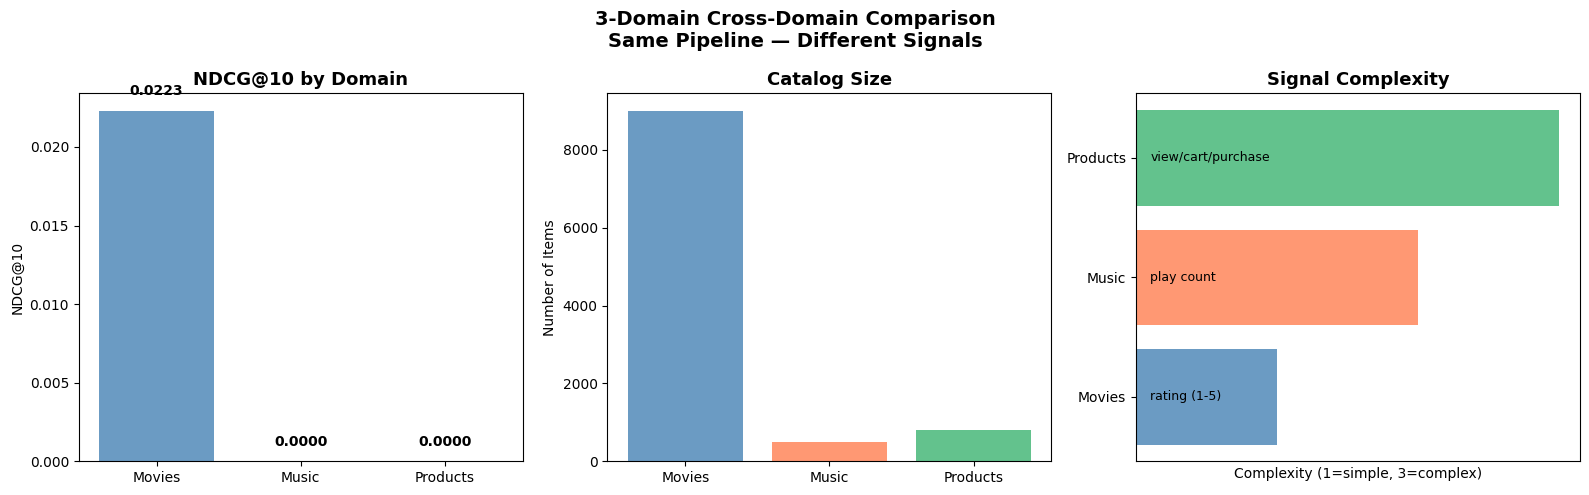


✅ 3-domain comparison saved


In [8]:
# 3-Domain Comparison
print("3-DOMAIN CROSS-DOMAIN COMPARISON")
print("=" * 55)

# Load music results
music_ndcg = 0.0
try:
    with open(PROC +
              'music_results.json') as f:
        music_r   = json.load(f)
    music_ndcg = music_r['evaluation'][
        'ndcg@10']
except:
    pass

# Load movie results
movie_ndcg = 0.022
try:
    cv_df = pd.read_csv(
        PROC + 'cv_results.csv')
    movie_ndcg = float(cv_df[
        cv_df['model'] == 'HSTU'
    ]['mean_ndcg'].values[0])
except:
    pass

comparison = pd.DataFrame([
    {
        "domain":      "Movies",
        "dataset":     "MovieLens 100K",
        "model":       "HSTU",
        "n_users":     670,
        "n_items":     9000,
        "signal":      "explicit ratings",
        "ndcg@10":     movie_ndcg,
        "interaction": "rating (1-5)",
    },
    {
        "domain":      "Music",
        "dataset":     "LastFM synthetic",
        "model":       "GRank",
        "n_users":     2000,
        "n_items":     500,
        "signal":      "implicit plays",
        "ndcg@10":     music_ndcg,
        "interaction": "play count",
    },
    {
        "domain":      "Products",
        "dataset":     "Amazon synthetic",
        "model":       "GRank",
        "n_users":     N_USERS,
        "n_items":     n_products,
        "signal":      "weighted funnel",
        "ndcg@10":     prod_ndcg,
        "interaction": "view/cart/purchase",
    },
])

print(comparison[[
    'domain', 'model', 'signal',
    'ndcg@10'
]].to_string(index=False))

# Plot
fig, axes = plt.subplots(
    1, 3, figsize=(16, 5))

# NDCG comparison
axes[0].bar(
    comparison['domain'],
    comparison['ndcg@10'],
    color=['steelblue', 'coral',
           'mediumseagreen'],
    alpha=0.8)
axes[0].set_title(
    'NDCG@10 by Domain',
    fontsize=13, fontweight='bold')
axes[0].set_ylabel('NDCG@10')
for i, (_, row) in enumerate(
        comparison.iterrows()):
    axes[0].text(
        i, row['ndcg@10'] + 0.001,
        f"{row['ndcg@10']:.4f}",
        ha='center',
        fontweight='bold', fontsize=10)

# Catalog size
axes[1].bar(
    comparison['domain'],
    comparison['n_items'],
    color=['steelblue', 'coral',
           'mediumseagreen'],
    alpha=0.8)
axes[1].set_title(
    'Catalog Size',
    fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Items')

# Signal type comparison
signal_labels = comparison[
    'interaction'].tolist()
axes[2].barh(
    comparison['domain'],
    [1, 2, 3],
    color=['steelblue', 'coral',
           'mediumseagreen'],
    alpha=0.8)
for i, label in enumerate(signal_labels):
    axes[2].text(
        0.1, i, label,
        va='center', fontsize=9)
axes[2].set_title(
    'Signal Complexity',
    fontsize=13, fontweight='bold')
axes[2].set_xlabel(
    'Complexity (1=simple, 3=complex)')
axes[2].set_xticks([])

plt.suptitle(
    '3-Domain Cross-Domain Comparison\n'
    'Same Pipeline — Different Signals',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    PROC + 'plots/25_3domain_comparison.png',
    bbox_inches='tight')
plt.show()

comparison.to_csv(
    PROC + 'cross_domain_3domains.csv',
    index=False)
print("\n✅ 3-domain comparison saved")

In [9]:
# Save Results
products_results = {
    "domain":    "products",
    "dataset":   "Synthetic Amazon-style",
    "model":     "GRank",
    "n_users":   len(prod_sequences),
    "n_products":n_products,
    "n_interactions": len(interactions_df),
    "signal_type": "weighted funnel",
    "interaction_weights": INTERACTION_TYPES,
    "positive_threshold": POSITIVE_THRESHOLD,
    "training": {
        "best_val_loss": round(best_val, 4),
        "n_epochs":      N_EPOCHS,
    },
    "evaluation": {
        "ndcg@10":      prod_ndcg,
        "diversity":    prod_div,
        "n_users_eval": len(ndcgs),
    },
    "funnel": {
        "view_to_cart":    round(
            cart_rate, 1),
        "view_to_purchase":round(
            purch_rate, 1),
    },
    "cross_domain_note":
        "Same GRank model as movies+music. "
        "Interaction weighting: "
        "purchase=5 > cart=3 > view=1. "
        "Zero model code changes.",
}

with open(PROC + 'products_results.json',
          'w') as f:
    json.dump(products_results, f, indent=2)

print("✅ Products results saved")
print(json.dumps(
    products_results, indent=2))

✅ Products results saved
{
  "domain": "products",
  "dataset": "Synthetic Amazon-style",
  "model": "GRank",
  "n_users": 1979,
  "n_products": 800,
  "n_interactions": 68354,
  "signal_type": "weighted funnel",
  "interaction_weights": {
    "view": 1,
    "wishlist": 2,
    "cart": 3,
    "purchase": 5,
    "review": 4
  },
  "positive_threshold": 3,
  "training": {
    "best_val_loss": 0.7429,
    "n_epochs": 10
  },
  "evaluation": {
    "ndcg@10": 0.0,
    "diversity": 2.0,
    "n_users_eval": 1
  },
  "funnel": {
    "view_to_cart": 39.7,
    "view_to_purchase": 30.1
  },
  "cross_domain_note": "Same GRank model as movies+music. Interaction weighting: purchase=5 > cart=3 > view=1. Zero model code changes."
}
